# Top-Hat Jet — Flat θ_c Re-run & Degeneracy Analysis

> **Source**: copied from `../Top_Hat_Models_re_run_flat_theta.ipynb`

This notebook contains two main sections:

### 1. Universal Top-Hat Model
- 6 parameters with $\theta_c$ (in degrees) and $f_j$ treated separately
- $\epsilon$ degeneracy analysis: $f_j$ vs $\theta_c$ 2D posteriors
- $\theta^*$ effective angle calculation

### 2. Flat θ_c Model
- Re-parameterised Flat $\theta_c$ model
- Multi-population runs across all population synthesis samples

This is the only notebook containing the **degeneracy analysis** between $f_j$ and $\theta_c$.

In [37]:
%load_ext autoreload
%autoreload 2

import  src.init
import  emcee
import  corner
import  numpy                   as np 
import  matplotlib.pyplot       as plt
from    math                    import inf
from    pathlib                 import Path
from    src.top_hat.montecarlo  import *
from src.top_hat.plot           import TopHatPlotter

plt.style.use('./configurations/style.mplstyle') #? Custom style, makes plots easier to read

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
datafiles   = Path("datafiles")
N_WALKERS   = 20

# Overall Universal Top Hat

In [39]:
# Model configuration
N_PARAMS        = 6
PARAM_NAMES     = ["A_index", "L_L0", "L_mu_E", "sigma_E", "theta_c_deg", "f_j"]
THETA_MAX_DEG   = 25 # degrees
MAX_FJ          = 10

def log_prior(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_deg, fj = thetas
    
    if not (1.5 < A_index       < 12)               : return -inf
    if not (-2  < L_L0          < 6)                : return -inf
    if not (1   < L_mu_E        < 6.5)              : return -inf
    if not (0   < sigma_E       < 1.8)              : return -inf
    if not (0   < theta_c_deg   < THETA_MAX_DEG)    : return -inf
    if not (0   < fj            < MAX_FJ)           : return -inf

    return 0.0 # Uniform prior

def log_likelihood_default(thetas, params_in, distances, k_interpolator, n_events=10_000):
    """
    Simulate exactly n_years of GRB observations.
    """
    A_index, L_L0, L_mu_E, sigma_E, theta_c_deg, fj = thetas

    # Calculate epsilon from f_j and theta_c
    theta_c_rad             = np.radians(theta_c_deg)
    geometric_factor        = 1 - np.cos(theta_c_rad)
    epsilon                 = fj * geometric_factor

    gbm_eff                 = 0.6
    
    # Calculate expected number of GRBs for n_years
    n_years                 = params_in.triggered_years 
    intrinsic_rate_per_year = epsilon * len(params_in.z_arr) * gbm_eff
    expected_total_events   = intrinsic_rate_per_year * n_years
    
    if expected_total_events < 10:
        return -inf, -inf, -inf, -inf, -inf

    results                     = simplified_montecarlo(thetas, n_events, params_in, distances, k_interpolator)
    
    trigger_mask, analysis_mask = apply_detection_cuts(results["p_flux"], results["E_p_obs"])
    
    if np.sum(analysis_mask) <= 3:
        return -inf, -inf, -inf, -inf, -inf
    
    detected_events         = np.sum(trigger_mask)
    detection_efficiency    = detected_events / n_events

    predicted_detections    = expected_total_events * detection_efficiency

    # Observed detections in the actual catalog
    observed_detections     = params_in.yearly_rate * params_in.triggered_years

    l1                      = score_func_cvm(results["p_flux"][analysis_mask], params_in.pflux_data, params_in.rng)
    l2                      = score_func_cvm(results["E_p_obs"][analysis_mask], params_in.epeak_data, params_in.rng)
    l3                      = poiss_log(k=observed_detections, mu=predicted_detections)
    l4                      = np.sum(trigger_mask) / n_events
    
    return l1 + l2 + l3, l1, l2, l3, l4

def initialize_walkers(n_walkers):
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2, 3, n_walkers),           # A_index
        np.random.uniform(2, 4.0, n_walkers),         # L_L0
        np.random.uniform(2.0, 4.0, n_walkers),       # L_mu_E
        np.random.uniform(0.2, 1, n_walkers),         # sigma_E
        np.random.uniform(1, 15, n_walkers),          # theta_c_deg ← NEW!
        np.random.uniform(0.5, 2, n_walkers),         # f_j ← NEW!
    ])

In [40]:
# Where to find the datafiles and save the outputs
output_dir_eps  = src.init.create_run_dir(f"Epsilon_test_flat_theta")
params = {
    "alpha"         : -0.67,    # 2/3 from synchrotron
    "beta_s"        : -2.59,    # Average value from GRBs
    "n"             : 2,        # Smoothly broken power law curvature
    "theta_c"       : 3.4,      # Ghirlanda half-angle of jet core (from GW170817)
    "theta_v_max"   : 10,       # Maximum viewing angle of the jet (in degrees)
    "z_model"      : 'fiducial_Hrad_A1.0'    #? Optional, model to use for redshift distribution
}
default_params, _, data_dict = src.init.initialize_simulation(datafiles, params=params) #? Catalogue data from fermi GBM

print(f"Total events in the catalogue: {len(default_params.pflux_data)}")

n_walkers       = 20
n_steps         = 60_000

k_interpolator  = create_k_interpolator()

log_likelihood_default_in = create_log_probability_function(
    log_prior_func          =   log_prior,
    log_likelihood_func     =   log_likelihood_default,
    params_in               =   default_params,
    k_interpolator          =   k_interpolator
)

filename    = output_dir_eps / "emcee.h5"
initial_pos, n_steps, backend = check_and_resume_mcmc(
    filename    =   filename, 
    n_steps     =   n_steps, 
    initialize_walkers_func   =   initialize_walkers, 
    n_walkers   =   n_walkers
) 

sampler = run_mcmc(
    log_probability_func    =   log_likelihood_default_in,
    initial_walkers         =   initial_pos,
    n_iterations            =   n_steps,
    n_walkers               =   n_walkers,
    n_params                =   N_PARAMS,
    backend                 =   backend,
)

Loading existing directory  : Output_files/Epsilon_test_flat_theta
Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
Total events in the catalogue: 268
Already completed this run


0it [00:00, ?it/s]


In [41]:
backend     = emcee.backends.HDFBackend(output_dir_eps / "emcee.h5")

In [42]:
# Cell: Plotting results
# After running MCMC
plotter         = TopHatPlotter(
    backend     =   backend,
    output_dir  =   output_dir_eps,
    model_type  =   "theta_c",  # or "flat_theta", "lognormal_theta"
    burn_in     =   1000,
    thin        =   15
)

# Generate all plots
distances = compute_luminosity_distance(default_params.z_arr)
summary = plotter.generate_all_plots(
    mc_func         =   simplified_montecarlo,
    params_in       =   default_params,
    distances       =   distances,
    k_interpolator  =   k_interpolator
)

print(summary)  # Print LaTeX table

Generating corner plot...
(78660, 6)
Generating likelihood evolution...
Generating autocorrelation plot...
Generating corner plot for last two parameters...
Generating CDF comparison...
All plots saved to: Output_files/Epsilon_test_flat_theta
\begin{tabular}{lc}
\hline
Parameter & Value \\
\hline
$k$ & $5.311_{-2.388}^{+4.227}$ \\
$\log_{10}(L_0)$ & $3.192_{-0.622}^{+0.527}$ \\
$\log_{10}(\mu_E)$ & $3.388_{-0.138}^{+0.233}$ \\
$\sigma_E$ & $0.369_{-0.062}^{+0.119}$ \\
$\theta_c$ (deg) & $3.132_{-2.015}^{+9.239}$ \\
$f_j$ & $1.971_{-1.773}^{+4.307}$ \\
\hline
\end{tabular}


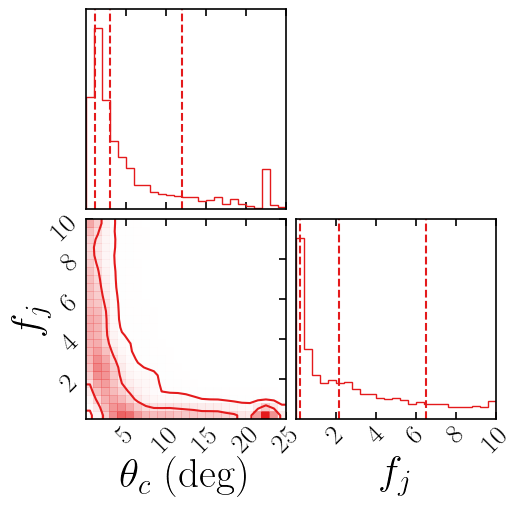

In [56]:
plotter         = TopHatPlotter(
    backend     =   backend,
    output_dir  =   output_dir_eps,
    model_type  =   "theta_c",  # or "flat_theta", "lognormal_theta"
    burn_in     =   5000,
    thin        =   15
)

plotter.plot_corner_last_two()

Saved plot to Output_files/Epsilon_test_flat_theta/degeneracy_concept_plot.pdf


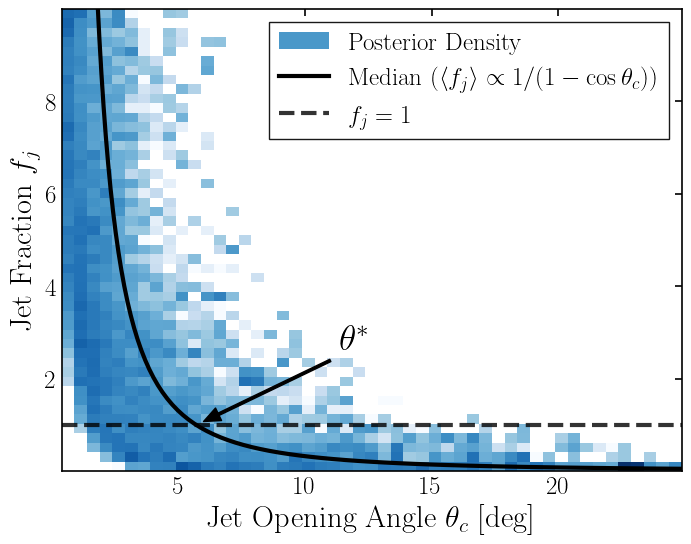

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import binned_statistic


# 1. Get samples from the backend
# discard burn-in and thin as needed
samples = backend.get_chain(discard=5_000, thin=15, flat=True)
theta_c_samples = samples[:, 4]  # Index 4 is theta_c_deg
fj_samples      = samples[:, 5]  # Index 5 is f_j

# 2. Define Log Bins for theta_c
bin_count = 40
# Ensure we don't take log of <= 0 (though theta_c should be > 0)
min_val = max(np.min(theta_c_samples), 0.1) 
max_val = np.max(theta_c_samples)
theta_bins = np.logspace(np.log10(min_val), np.log10(max_val), bin_count + 1)

# 3. Calculate the median f_j in each log bin
bin_medians, bin_edges, _ = binned_statistic(
    theta_c_samples, fj_samples, statistic='median', bins=theta_bins
)
# Geometric center for log bins (better visual representation in log plot)
bin_centers = np.sqrt(bin_edges[1:] * bin_edges[:-1])

# 4. Find theta* (where median f_j = 1)
valid_mask = ~np.isnan(bin_medians)
# Interpolate: given f_j, find theta_c
interpolator = interp1d(bin_medians[valid_mask], bin_centers[valid_mask], bounds_error=False, fill_value="extrapolate")
theta_star = interpolator(1.0)
# 1. Prepare Data
x_vals = theta_c_samples
y_vals = fj_samples

# Calculate unbiased epsilon (representing the true physics)
theta_c_rad = np.radians(theta_c_samples)
geom_factor = 1 - np.cos(theta_c_rad)
epsilon_samples = fj_samples * geom_factor

mask_high = theta_c_samples > 6.0
eps_med_unbiased = np.median(epsilon_samples[mask_high])
theta_star_rad = np.arccos(1 - eps_med_unbiased)
theta_star = np.degrees(theta_star_rad)

# 2. Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# 2D Histogram (Background)
log_bins_x = np.logspace(np.log10(x_vals.min()), np.log10(x_vals.max()), 50)
lin_bins_x = np.linspace(x_vals.min(), x_vals.max(), 50)
lin_bins_y = np.linspace(y_vals.min(), y_vals.max(), 50)

h = ax.hist2d(x_vals, y_vals, bins=[lin_bins_x, lin_bins_y], cmap='Blues', density=True, 
              norm=mcolors.LogNorm(), cmin=1e-5)

x_line = np.logspace(np.log10(x_vals.min()), np.log10(x_vals.max()), 100)
x_line_rad = np.radians(x_line)
y_line = eps_med_unbiased / (1 - np.cos(x_line_rad))

line, = ax.plot(x_line, y_line, color='black', linestyle='-', linewidth=3, 
        label=r'Median ($\left<f_j \right> \propto 1/(1 - \cos\theta_c$))')

# Theta* Annotation (Concept only)
line2 = ax.axhline(1, color='k', linestyle='--', alpha=0.8, linewidth=3, label=r'$f_j = 1$')
 
ax.annotate(
    r'$\theta^*$', 
    xy=(theta_star, 1), 
    xytext=(theta_star * 2, 2.5), 
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.8, headwidth=10),
    fontsize=26,
    #bold
    fontweight='bold',
    verticalalignment='bottom'
)
from matplotlib.patches import Patch

# --- NEW: Custom Legend ---
legend_elements = [
    Patch(facecolor=plt.cm.Blues(0.6), edgecolor='none', label='Posterior Density'),
    line,
    line2
]
ax.legend(handles=legend_elements, fontsize=18, loc='upper right')
# --------------------------
# Formatting
ax.set_xscale('linear')
ax.set_yscale('linear')
ax.set_xlabel(r'Jet Opening Angle $\theta_c$ [deg]', fontsize=22)
ax.set_ylabel(r'Jet Fraction $f_j$', fontsize=22)
# make ticks larger
ax.tick_params(axis='both', which='major', labelsize=18)
plt.savefig(output_dir_eps / "degeneracy_concept_plot.pdf", dpi=300)
print(f"Saved plot to {output_dir_eps / 'degeneracy_concept_plot.pdf'}")
plt.show()

# Flat Theta

In [84]:
# Cell: Model-specific definitions

from src.top_hat.montecarlo import *

N_PARAMS    = 6
PARAM_NAMES = ["A_index", "L_L0", "L_mu_E", "sigma_E", "theta_c_max", "fj"]

def log_prior_ft(thetas, max_fj = 10):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_max, fj = thetas
    
    if not (1.5 < A_index < 12): return -inf
    if not (-2 < L_L0 < 7): return -inf
    if not (0.1 < L_mu_E < 7): return -inf
    if not (0 < sigma_E < 2.5): return -inf
    if not (1 < theta_c_max < 25): return -inf
    if not (0 < fj < max_fj): return -inf
    
    return 0.0

def log_likelihood_flat_theta(thetas, params_in, distances, k_interpolator, n_events=10_000):
    theta_c_max, fj             = thetas[4], thetas[5]
    gbm_eff                     = 0.6
    geometric_efficiency        = calculate_geometric_efficiency_flat(theta_c_max)
    triggered_years             = params_in.triggered_years
    epsilon                     = geometric_efficiency * fj
    n_years                     = triggered_years
    intrinsic_rate_per_year     = epsilon * len(params_in.z_arr) * gbm_eff
    expected_events             = intrinsic_rate_per_year * n_years
    #n_events                    = int(expected_events)
    
    results                     = simplified_montecarlo(thetas, n_events, params_in, distances, k_interpolator)
    
    trigger_mask, analysis_mask = apply_detection_cuts(results["p_flux"], results["E_p_obs"])
    
    if np.sum(analysis_mask) <= 3:
        return -inf, -inf, -inf, -inf, -inf
    
    
    triggered_events        = np.sum(trigger_mask)
    physics_efficiency      = triggered_events  / n_events

    #simulated_rate_per_year = triggered_events / n_years
    #predicted_detections    = simulated_rate_per_year * params_in.triggered_years
    
    predicted_detections    = expected_events * physics_efficiency
    observed_detections     = params_in.yearly_rate * params_in.triggered_years

    l1 = score_func_cvm(results["p_flux"][analysis_mask], params_in.pflux_data, params_in.rng)
    l2 = score_func_cvm(results["E_p_obs"][analysis_mask], params_in.epeak_data, params_in.rng)
    l3 = poiss_log(k=observed_detections, mu=predicted_detections)

    return l1 + l2 + l3, l1, l2, l3, physics_efficiency

def initialize_walkers_ft(n_walkers):
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2, 3, n_walkers),
        np.random.uniform(2, 4.0, n_walkers),
        np.random.uniform(2.0, 4.0, n_walkers),
        np.random.uniform(0.2, 1, n_walkers),
        np.random.uniform(1, 10, n_walkers),    # theta_c_max
        np.random.uniform(0.5, 4, n_walkers),   # fj
    ])

In [58]:
# Where to find the datafiles and save the outputs
output_dir_ft  = src.init.create_run_dir(f"Paper_Results/Flat_Theta/fiducial")

default_params, _, data_dict = src.init.initialize_simulation(datafiles, params=params) #? Catalogue data from fermi GBM

print(f"Total events in the catalogue: {len(default_params.pflux_data)}")

n_walkers       = 20
n_steps         = 60_000

k_interpolator  = create_k_interpolator()
initial_walkers = initialize_walkers_ft(n_walkers)

log_likelihood_default_in_ft = create_log_probability_function(
    log_prior_func          =   log_prior_ft,
    log_likelihood_func     =   log_likelihood_flat_theta,
    params_in               =   default_params,
    k_interpolator          =   k_interpolator
)

filename    = output_dir_ft / "emcee.h5"
initial_pos, n_steps, backend = check_and_resume_mcmc(
    filename                    =   filename, 
    n_steps                     =   n_steps, 
    initialize_walkers_func     =   initialize_walkers_ft, 
    n_walkers                   =   n_walkers
)

sampler = run_mcmc(
    log_probability_func    =   log_likelihood_default_in_ft,
    initial_walkers         =   initial_pos,
    n_iterations            =   n_steps,
    n_walkers               =   n_walkers,
    n_params                =   N_PARAMS,
    backend                 =   backend,
)

Loading existing directory  : Output_files/Paper_Results/Flat_Theta/fiducial
Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
Total events in the catalogue: 268
Already completed this run


0it [00:00, ?it/s]


In [86]:
# Make sure we're using the backend from the flat_theta run
backend_ft  = emcee.backends.HDFBackend(output_dir_ft / "emcee.h5")

plotter_flat_theta = TopHatPlotter(
    backend     =   backend_ft,  # Use explicit backend variable
    output_dir  =   output_dir_ft,
    model_type  =   "flat_theta",
    burn_in     =   1000,
    thin        =   15
)   

# Generate all plots
distances = compute_luminosity_distance(default_params.z_arr)
summary = plotter_flat_theta.generate_all_plots(
    mc_func=simplified_montecarlo,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    geometric_eff_func=calculate_geometric_efficiency_flat
)
print(summary)

Generating corner plot...
(78660, 6)
Generating likelihood evolution...
Generating autocorrelation plot...
Generating corner plot for last two parameters...
Generating CDF comparison...
All plots saved to: Output_files/Paper_Results/Flat_Theta/fiducial
\begin{tabular}{lc}
\hline
Parameter & Value \\
\hline
$k$ & $6.127_{-2.836}^{+3.757}$ \\
$\log_{10}(L_0)$ & $3.153_{-0.480}^{+0.429}$ \\
$\log_{10}(\mu_E)$ & $3.425_{-0.171}^{+0.373}$ \\
$\sigma_E$ & $0.394_{-0.085}^{+0.155}$ \\
$\theta_{c,\max}$ (deg) & $4.197_{-2.365}^{+5.036}$ \\
$f_j$ & $2.827_{-2.156}^{+3.876}$ \\
\hline
\end{tabular}


Mean fj: 2.8314288667354264


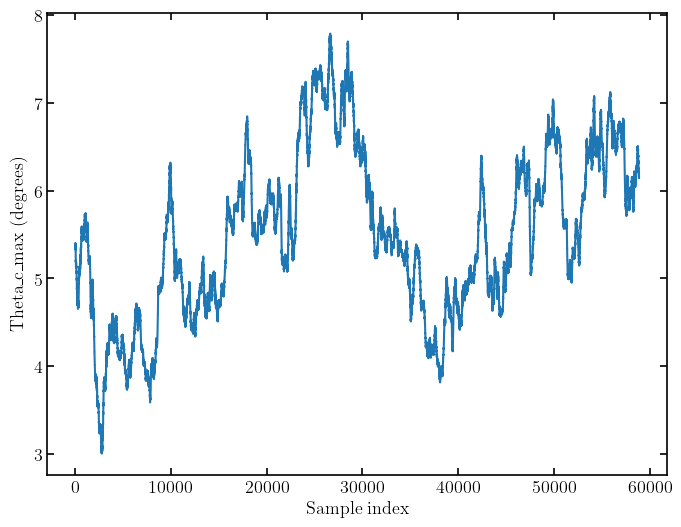

In [60]:
fj = backend_ft.get_chain(discard=1000, thin=20, flat=True)[:,-1]
print(f"Mean fj: {np.median(fj)}")

theta_c_max = backend_ft.get_chain(discard=1000, thin=20, flat=True)[:,-2]

running_mean_theta_c = np.convolve(theta_c_max, np.ones(100)/100, mode='valid')
plt.plot(running_mean_theta_c)
plt.xlabel("Sample index")
plt.ylabel("Theta_c_max (degrees)")
plt.show()

# Log-Normal

In [61]:
# Cell: Model-specific definitions

from src.top_hat.montecarlo import *

N_PARAMS        = 6
PARAM_NAMES     = ["A_index", "L_L0", "L_mu_E", "sigma_E", "theta_c_med_10", "fj"]

def log_prior_log_normal(thetas, max_fj=10):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_med_10, fj = thetas

    if not (1.5 < A_index < 12): return -inf
    if not (-2 < L_L0 < 7): return -inf
    if not (0.1 < L_mu_E < 7): return -inf
    if not (0 < sigma_E < 2.5): return -inf
    if not (np.log10(1) < theta_c_med_10 < np.log10(25)): return -inf
    if not (0 < fj < max_fj): return -inf
    
    return 0.0

geom_eff_interp = create_geometric_efficiency_lognormal_interpolator(sigma_theta_c=0.5)
def log_likelihood_log_normal(thetas, params_in, distances, k_interpolator, n_events=10_000):
    theta_c_med_10, fj          = thetas[4], thetas[5]
    
    gbm_eff                     = 0.6
    geometric_efficiency        = geom_eff_interp(theta_c_med_10)
    triggered_years             = params_in.triggered_years
    epsilon                     = geometric_efficiency * fj

    factor                      = 1 # Simulate less as the effieicny is already making this hella slow
    n_years                     = triggered_years / factor
    intrinsic_rate_per_year     = epsilon * len(params_in.z_arr) * gbm_eff
    expected_events             = intrinsic_rate_per_year * n_years
    #n_events                    = int(expected_events)
    
    #if n_events < 50/factor:  # We have 300 events in the data, so even with perfect detection we need at least this many
    #    return -inf, -inf, -inf, -inf, -inf
    
    results                     = simplified_montecarlo(thetas, n_events, params_in, distances, k_interpolator)
    
    trigger_mask, analysis_mask = apply_detection_cuts(results["p_flux"], results["E_p_obs"])
    
    if np.sum(analysis_mask) <= 3:
        return -inf, -inf, -inf, -inf, -inf
    
    triggered_events        = np.sum(trigger_mask)
    physics_efficiency      = triggered_events  / n_events

    #simulated_rate_per_year = triggered_events / n_years
    #predicted_detections    = simulated_rate_per_year * params_in.triggered_years
    
    predicted_detections    = expected_events * physics_efficiency
    observed_detections     = params_in.yearly_rate * params_in.triggered_years
    
    l1 = score_func_cvm(results["p_flux"][analysis_mask], params_in.pflux_data, params_in.rng)
    l2 = score_func_cvm(results["E_p_obs"][analysis_mask], params_in.epeak_data, params_in.rng)
    l3 = poiss_log(k=observed_detections, mu=predicted_detections)
        
    return l1 + l2 + l3, l1, l2, l3, physics_efficiency

# log_likelihood similar to flat case but uses calculate_geometric_efficiency_lognormal

def initialize_walkers_log_normal(n_walkers):
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2, 3, n_walkers),
        np.random.uniform(2, 4.0, n_walkers),
        np.random.uniform(2.0, 4.0, n_walkers),
        np.random.uniform(0.2, 1, n_walkers),
        np.random.uniform(np.log10(5), np.log10(10), n_walkers),  
        np.random.uniform(0.5, 1, n_walkers),
    ])

KeyboardInterrupt: 

In [ ]:
output_dir_lm                       = src.init.create_run_dir(f"Paper_Results/Lognormal_Theta/fiducial")

Loading existing directory  : Output_files/Paper_Results/Lognormal_Theta/fiducial


In [ ]:
# Where to find the datafiles and save the outputs

default_params, _, data_dict        = src.init.initialize_simulation(datafiles, params=params) #? Catalogue data from fermi GBM

print(f"Total events in the catalogue: {len(default_params.pflux_data)}")

n_walkers       = 20
n_steps         = 90_000

k_interpolator  = create_k_interpolator()

log_likelihood_default_in_log_normal = create_log_probability_function(
    log_prior_func          =   log_prior_log_normal,
    log_likelihood_func     =   log_likelihood_log_normal,
    params_in               =   default_params,
    k_interpolator          =   k_interpolator
)

initial_pos, n_steps, backend = check_and_resume_mcmc(
    filename                    =    output_dir_lm / "emcee.h5", 
    n_steps                     =   n_steps, 
    initialize_walkers_func     =   initialize_walkers_log_normal, 
    n_walkers                   =   n_walkers
)

sampler = run_mcmc(
    log_probability_func    =   log_likelihood_default_in_log_normal,
    initial_walkers         =   initial_pos,
    n_iterations            =   n_steps,
    n_walkers               =   n_walkers,
    n_params                =   N_PARAMS,
    backend                 =   backend,
)

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
Total events in the catalogue: 268
Already completed this run


0it [00:00, ?it/s]


In [ ]:
# plot
backend_ln = emcee.backends.HDFBackend(output_dir_lm / "emcee.h5")

plotter_log_normal = TopHatPlotter(
    backend     =   backend_ln,
    output_dir  =   output_dir_lm,
    model_type  =   "lognormal_theta",
    burn_in     =   3_000,
    thin        =   15
)

# Generate all plots
distances = compute_luminosity_distance(default_params.z_arr)
summary = plotter_log_normal.generate_all_plots(
    mc_func=simplified_montecarlo,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    geometric_eff_func=geom_eff_interp
)

print(summary)  # Print LaTeX table

Generating corner plot...
(116000, 6)
Generating likelihood evolution...
Generating autocorrelation plot...
Generating corner plot for last two parameters...
Generating CDF comparison...
All plots saved to: Output_files/Paper_Results/Lognormal_Theta/fiducial
\begin{tabular}{lc}
\hline
Parameter & Value \\
\hline
$k$ & $6.483_{-3.101}^{+3.772}$ \\
$\log_{10}(L_0)$ & $2.947_{-0.484}^{+0.517}$ \\
$\log_{10}(\mu_E)$ & $3.472_{-0.207}^{+0.646}$ \\
$\sigma_E$ & $0.420_{-0.100}^{+0.231}$ \\
$\log_{10}(\theta_{c,\mathrm{med}})$ & $0.259_{-0.200}^{+0.311}$ \\
$f_j$ & $0.650_{-0.529}^{+1.825}$ \\
\hline
\end{tabular}


In [20]:
theta_c_med_10_samples = backend_ln.get_chain(discard=1000, thin=20, flat=True)[:,-2]
print(f"Mean theta_c: {(10**np.median(theta_c_med_10_samples))} degrees")

Mean theta_c: 1.8277149663694712 degrees


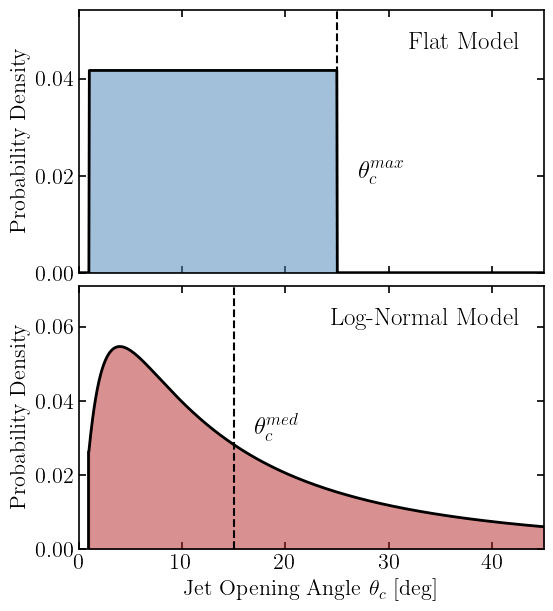

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# --- Parameters ---
# Use the best-fit values calculated previously
# If running this cell standalone, replace these with specific values (e.g., 10.0 and 5.0)
val_flat_max = 25  # Parameter theta_c_max for Flat model
val_log_med  = 15  # Parameter theta_c_med for Log-Normal model
sigma_log10  = 0.5
s = sigma_log10 * np.log(10)

# --- Setup Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)
plt.subplots_adjust(hspace=0.05) # Adjust space between plots

# ==========================================
# 1. Flat Distribution (Top Panel)
# ==========================================
# Defined on [1, theta_max]
x_flat = np.linspace(0, 90, 2000)
pdf_flat = np.zeros_like(x_flat)

# Calculate height to normalize area to 1 over [1, theta_max]
if val_flat_max > 1:
    height = 1.0 / (val_flat_max - 1.0)
    mask_flat = (x_flat >= 1) & (x_flat <= val_flat_max)
    pdf_flat[mask_flat] = height

# Plot
ax1.plot(x_flat, pdf_flat, 'k-', lw=2)
ax1.fill_between(x_flat, 0, pdf_flat, color='steelblue', alpha=0.5)

# Annotation
ax1.axvline(val_flat_max, color='k', linestyle='--', lw=1.5)
ax1.text(val_flat_max + 2, height/2, r'$\theta_{c}^{max}$', fontsize=18, va='center')

# Formatting
ax1.set_ylabel(r'Probability Density', fontsize=16)
ax1.text(0.95, 0.85, 'Flat Model', transform=ax1.transAxes, ha='right', fontsize=18, weight='bold')
ax1.set_ylim(0, height * 1.3)

# ==========================================
# 2. Log-Normal Distribution (Bottom Panel)
# ==========================================
# Defined on [1, 90]
scale = val_log_med # Scale is the Median

# Calculate Normalization for truncation [1, 45]
cdf_45 = lognorm.cdf(45, s=s, scale=scale)
cdf_1  = lognorm.cdf(1, s=s, scale=scale)
norm   = cdf_45 - cdf_1

# Calculate PDF
x_ln = np.linspace(1, 45, 2000)
pdf_ln_raw = lognorm.pdf(x_ln, s=s, scale=scale)
pdf_ln = pdf_ln_raw / norm

# Plot
ax2.plot(x_ln, pdf_ln, 'k-', lw=2)
ax2.fill_between(x_ln, 0, pdf_ln, color='firebrick', alpha=0.5)
# black line at x = 1 to show lower limit up till the value of the pdf at x=1
ax2.plot([0.952, 0.952], [0, pdf_ln[0]*0.98], 'k-', lw=2)

# Annotation for Median
ax2.axvline(val_log_med, color='k', linestyle='--', lw=1.5)
ax2.text(val_log_med + 2, np.max(pdf_ln)/2 + 0.1 * np.max(pdf_ln), r'$\theta_{c}^{med}$', fontsize=18, va='center')

# Formatting
ax2.set_ylabel(r'Probability Density', fontsize=16)
ax2.set_xlabel(r'Jet Opening Angle $\theta_c$ [deg]', fontsize=16)
ax2.text(0.95, 0.85, 'Log-Normal Model', transform=ax2.transAxes, ha='right', fontsize=18, weight='bold')
ax2.set_xlim(0, 45)
ax2.set_ylim(0, np.max(pdf_ln) * 1.3)
#make ticks larger

ax1.tick_params(axis='both', which='major', labelsize=16)   
ax2.tick_params(axis='both', which='major', labelsize=16)

# Save
plt.savefig(output_dir_eps / "paper_model_distributions.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [166]:
1/0

ZeroDivisionError: division by zero

# Multiple Populations

In [26]:
from multiprocessing import Pool
from pathlib import Path
import src.init
from src.spectral_models import DEFAULT_SPECTRAL_PARAMS
population_folder = Path("datafiles") / "populations" / "samples"
#with glob find all the samples_*.dat files
samples         = list(population_folder.glob('samples_*.dat'))
samp_names      = [samp.name.split('samples_')[1].split('_BNSs')[0] for samp in samples]
print(f"Found {len(samples)} samples: {samp_names}")
total_num_samp  = len(samp_names)
datafiles       = Path("datafiles")

Found 64 samples: ['fiducial_delayed_A0.5', 'fiducial_delayed_A1.0', 'fiducial_delayed_A3.0', 'fiducial_delayed_A5.0', 'fiducial_fmtbse_A0.5', 'fiducial_fmtbse_A1.0', 'fiducial_fmtbse_A3.0', 'fiducial_fmtbse_A5.0', 'fiducial_HGoptimistic_A0.5', 'fiducial_HGoptimistic_A1.0', 'fiducial_HGoptimistic_A3.0', 'fiducial_HGoptimistic_A5.0', 'fiducial_Hrad_5M_A0.5', 'fiducial_Hrad_5M_A1.0', 'fiducial_Hrad_5M_A3.0', 'fiducial_Hrad_5M_A5.0', 'fiducial_Hrad_A0.5', 'fiducial_Hrad_A1.0', 'fiducial_Hrad_A3.0', 'fiducial_Hrad_A5.0', 'fiducial_kick150_A0.5', 'fiducial_kick150_A1.0', 'fiducial_kick150_A3.0', 'fiducial_kick150_A5.0', 'fiducial_kick265_A0.5', 'fiducial_kick265_A1.0', 'fiducial_kick265_A3.0', 'fiducial_kick265_A5.0', 'fiducial_klencki_A0.5', 'fiducial_klencki_A1.0', 'fiducial_klencki_A3.0', 'fiducial_klencki_A5.0', 'fiducial_l01_A0.5', 'fiducial_l01_A1.0', 'fiducial_l01_A3.0', 'fiducial_l01_A5.0', 'fiducial_notides_A0.5', 'fiducial_notides_A1.0', 'fiducial_notides_A3.0', 'fiducial_notides_

In [27]:
n_steps = 14_000

for z_test in samp_names:
    print(f"Processing population: {z_test} ({samp_names.index(z_test)+1}/{total_num_samp})")
    
    # --- Common Setup for this population ---
    params_pop = DEFAULT_SPECTRAL_PARAMS.copy()
    params_pop["z_model"] = z_test

    # Initialize simulation with specific population
    current_params, _, _ = src.init.initialize_simulation(datafiles, params_pop)
    
    # Pre-compute distances and interpolator
    k_interpolator = create_k_interpolator()

    # ==========================================
    # Model 1: Theta_c (Direct sampling) - 6 Parameters
    # ==========================================
    print(f"  >> Running Theta_c model for {z_test}...")
    output_dir_theta_c = src.init.create_run_dir(f"ProductionPop_Theta_c_10k/{z_test}", use_timestamp=False)
    filename_theta_c = output_dir_theta_c / "emcee.h5"
    
    # Create log prob function for Theta_c model
    log_prob_theta_c = create_log_probability_function(
        log_prior_func      = log_prior,                    # Uses theta_c + f_j
        log_likelihood_func = log_likelihood_default,       # Uses theta_c + f_j
        params_in           = current_params,
        k_interpolator      = k_interpolator
    )
    
    # Check resume status
    initial_pos_theta_c, steps_todo_theta_c, backend_theta_c = check_and_resume_mcmc(
        filename                = filename_theta_c,
        n_steps                 = n_steps,
        initialize_walkers_func = initialize_walkers,       # Returns 6 params
        n_walkers               = n_walkers
    )
    
    # Run if needed 
    if steps_todo_theta_c > 0:
        run_mcmc(
            log_probability_func = log_prob_theta_c,
            initial_walkers      = initial_pos_theta_c,
            n_iterations         = steps_todo_theta_c,
            n_walkers            = n_walkers, 
            n_params             = 6,                        # ← CHANGED FROM 5 TO 6
            backend              = backend_theta_c,      
        )
    else:
        print("     Theta_c model already completed.")

Processing population: fiducial_delayed_A0.5 (1/64)
Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
  >> Running Theta_c model for fiducial_delayed_A0.5...
Loading existing directory  : Output_files/ProductionPop_Theta_c_10k/fiducial_delayed_A0.5
Already completed this run
     Theta_c model already completed.
Processing population: fiducial_delayed_A1.0 (2/64)
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 342071 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
  >> Running Theta_c model for fiducial_d

100%|██████████| 1259/1259 [01:44<00:00, 12.05it/s]


Processing population: fiducial_notides_pericirc_A5.0 (44/64)
Using redshift model: samples_fiducial_notides_pericirc_A5.0_BNSs_0.dat with 241080 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
  >> Running Theta_c model for fiducial_notides_pericirc_A5.0...
Loading existing directory  : Output_files/ProductionPop_Theta_c_10k/fiducial_notides_pericirc_A5.0
Continuing from iteration 10000


100%|██████████| 4000/4000 [05:44<00:00, 11.60it/s]


Processing population: fiducial_pisnfarmer19_A0.5 (45/64)
Using redshift model: samples_fiducial_pisnfarmer19_A0.5_BNSs_0.dat with 62278 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
  >> Running Theta_c model for fiducial_pisnfarmer19_A0.5...
Loading existing directory  : Output_files/ProductionPop_Theta_c_10k/fiducial_pisnfarmer19_A0.5
Continuing from iteration 10000


...

100%|██████████| 4000/4000 [04:57<00:00, 13.43it/s]


Processing population: fiducial_xuli_A3.0 (63/64)
Using redshift model: samples_fiducial_xuli_A3.0_BNSs_0.dat with 276961 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
  >> Running Theta_c model for fiducial_xuli_A3.0...
Loading existing directory  : Output_files/ProductionPop_Theta_c_10k/fiducial_xuli_A3.0
Continuing from iteration 10000


100%|██████████| 4000/4000 [05:00<00:00, 13.30it/s]


Processing population: fiducial_xuli_A5.0 (64/64)
Using redshift model: samples_fiducial_xuli_A5.0_BNSs_0.dat with 409987 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 310, Trigger years: 16.66, Yearly rate: 18.61 events/year
  >> Running Theta_c model for fiducial_xuli_A5.0...
Loading existing directory  : Output_files/ProductionPop_Theta_c_10k/fiducial_xuli_A5.0
Continuing from iteration 10000


100%|██████████| 4000/4000 [05:12<00:00, 12.81it/s]


In [ ]:
1/0

ZeroDivisionError: division by zero

In [ ]:
%load_ext autoreload
%autoreload 2

from src.plots_oop_epsilon import ThetaCModelPlotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
# For Theta_c models (6 parameters)
run_name = "ProductionPop_Theta_c_10k"
BASE_DIR_THETA_C = Path(run_name)
OUTPUT_DIR_THETA_C = Path("Output_files") / run_name
OUTPUT_DIR_THETA_C.mkdir(parents=True, exist_ok=True)
DATA_FILES_DIR  = datafiles
SAMP_NAMES      = samp_names

plotter_theta_c = ThetaCModelPlotter(
    samp_names=SAMP_NAMES,
    base_dir=str(BASE_DIR_THETA_C),
    data_files_dir=str(DATA_FILES_DIR),
    output_dir  =str(OUTPUT_DIR_THETA_C),
    discard     =1000,
    thin        =20,
    k_params    =6,
    theta_c_idx =4,  # Index of theta_c in degrees
    fj_idx      =5,       # Index of fj in parameter array
)

# Generate all plots
#plotter_theta_c.plot_violins_fj(filename="fj_violin_plot.pdf", max_fj=10)
#plotter_theta_c.plot_fj_vs_rate(max_fj=10)

Loading and processing model data...
Successfully processed 64 models.


Saved plot to Output_files/ProductionPop_Theta_c_10k/fj_fraction_vs_rate.pdf


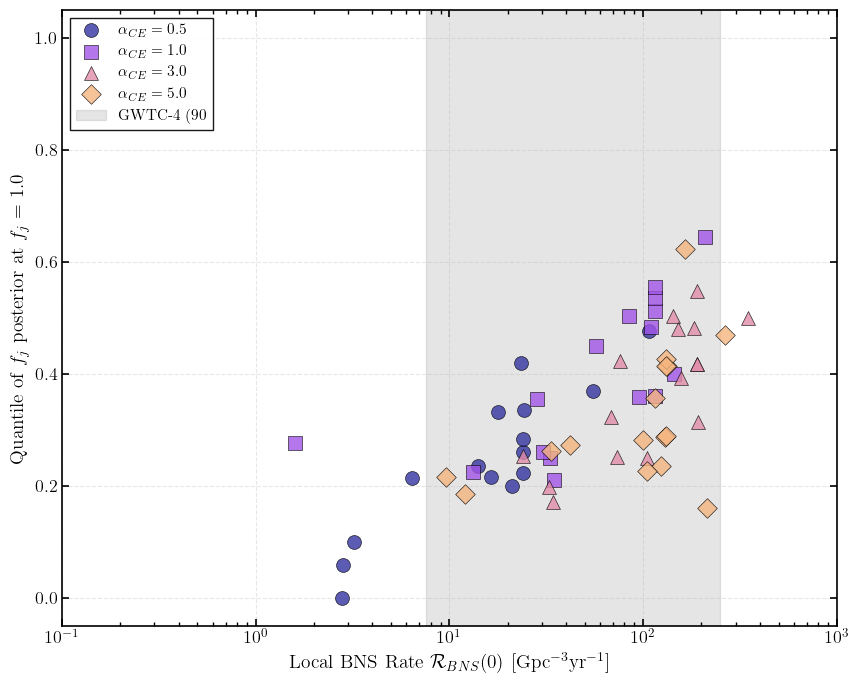

Saved plot to Output_files/ProductionPop_Theta_c_10k/theta_boundary_vs_rate.pdf


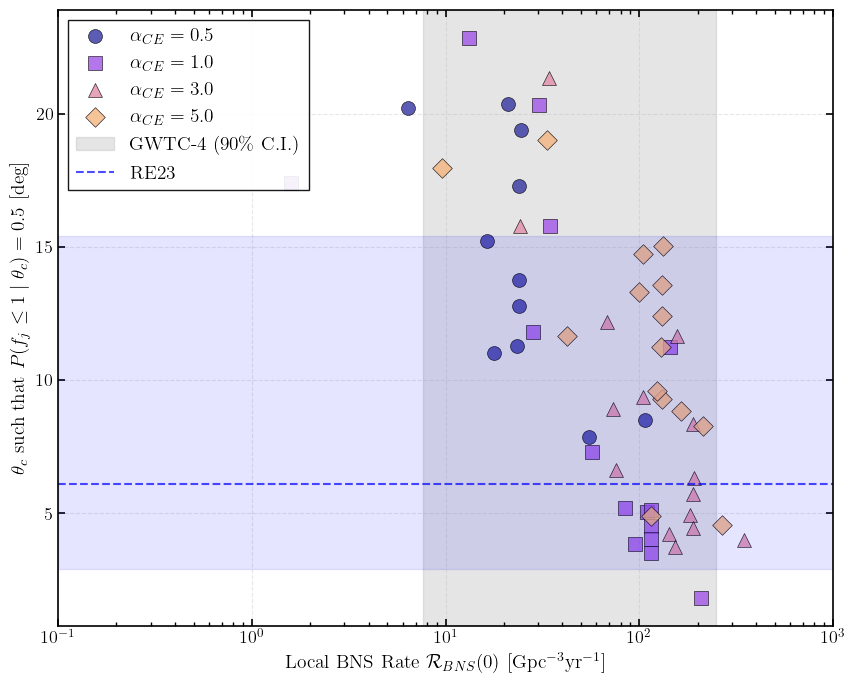

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Local BNS Rate $\\mathcal{R}_{BNS}(0)$ [Gpc$^{-3}$yr$^{-1}$]', ylabel='$\\theta_{c}$ such that $P(f_j \\leq 1 \\mid \\theta_{c}) = 0.5$ [deg]'>)

In [64]:
plotter_theta_c.plot_fj_fraction_vs_rate()
plotter_theta_c.plot_physical_theta_boundary_vs_rate()

Saved plot to Output_files/ProductionPop_Theta_c_10k/theta_star_robust_vs_rate.pdf


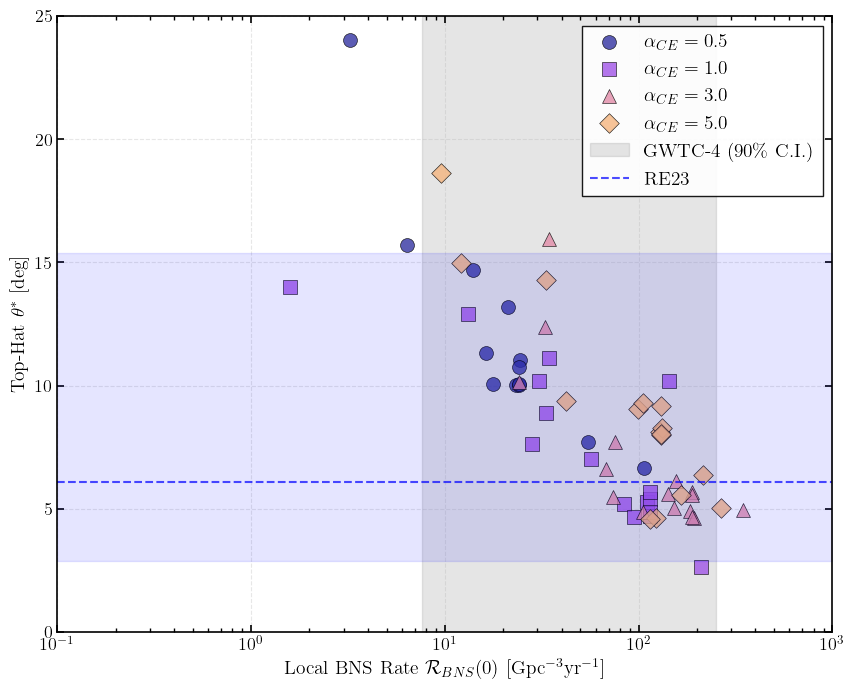

In [65]:
plotter_theta_c.plot_theta_star_robust_vs_rate()

Saved plot to Output_files/ProductionPop_Theta_c_10k/fj_violin_plot_fixed_angles.pdf


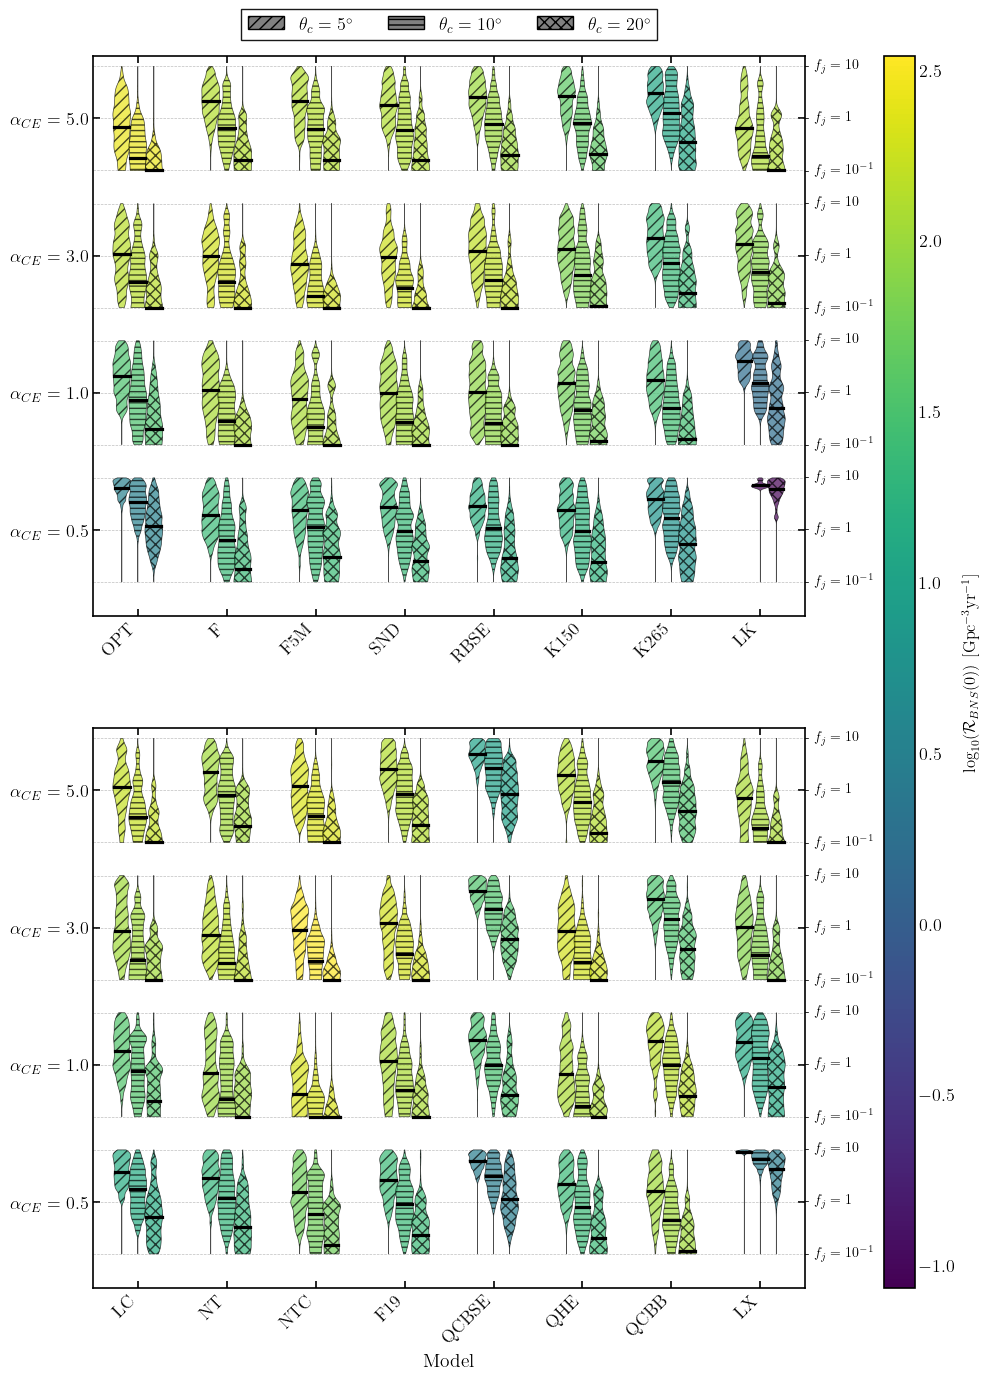

In [71]:
plotter_theta_c.plot_violins_fj_at_fixed_angles()

Saved plot to Output_files/ProductionPop_Theta_c_10k/epsilon_violin_plot.pdf


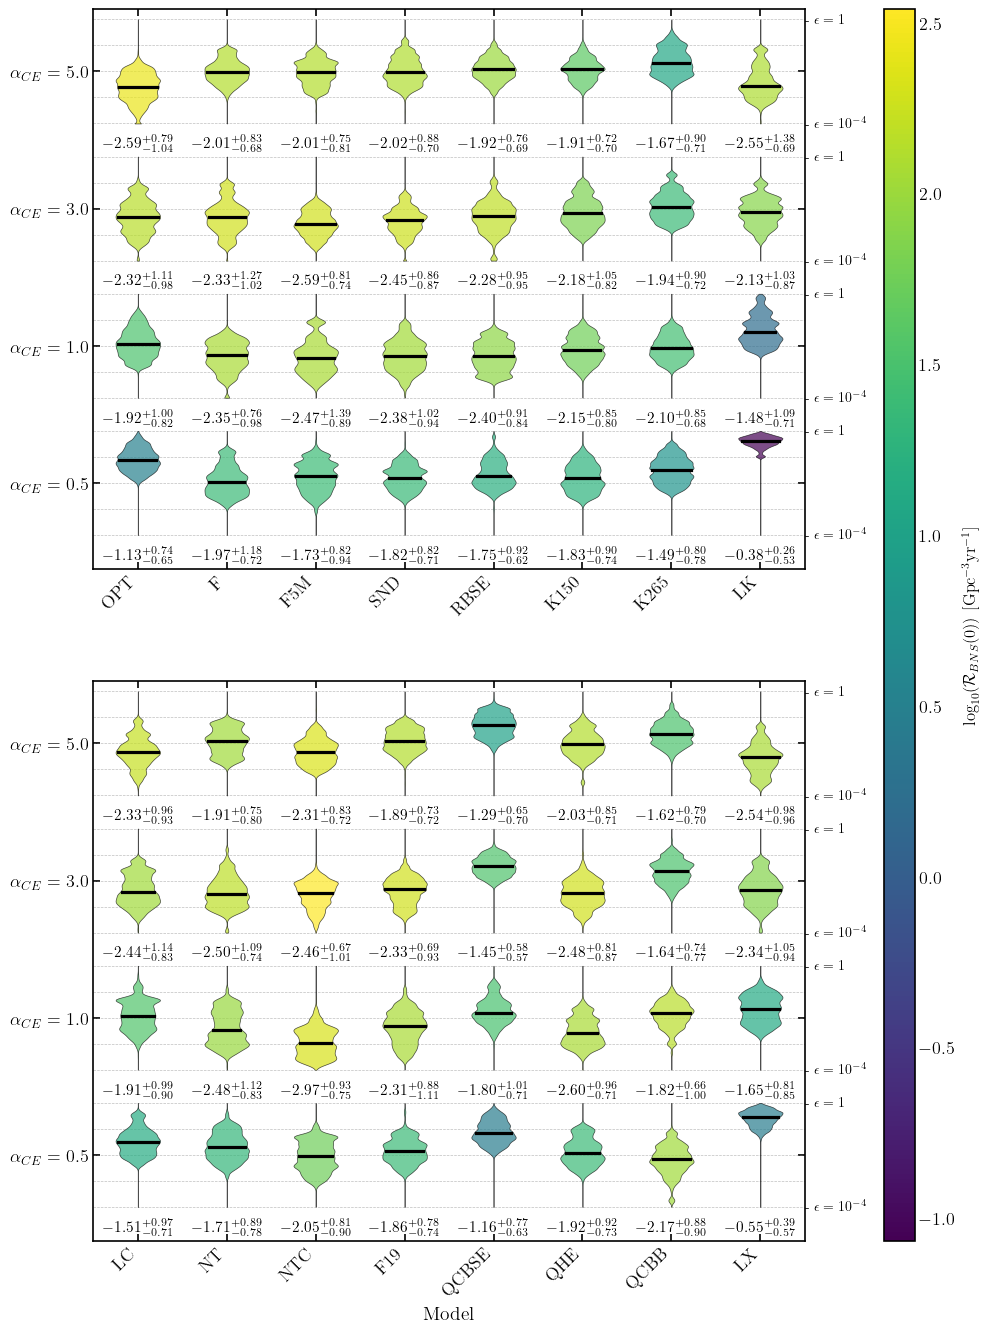

In [73]:
plotter_theta_c.plot_violins_epsilon()

Saved plot to Output_files/ProductionPop_Theta_c_10k/fj_fraction_vs_rate.pdf


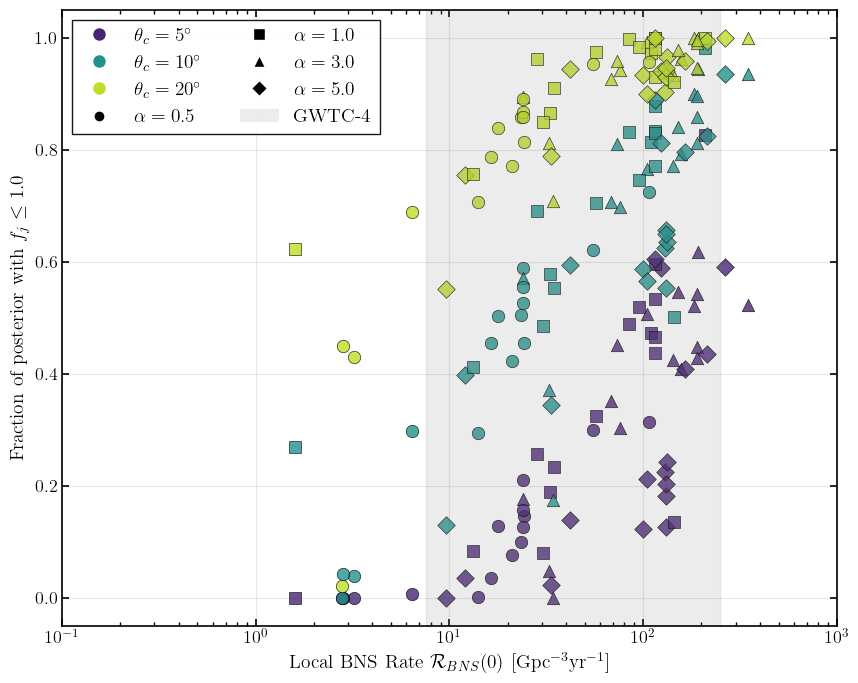

In [77]:
plotter_theta_c.plot_fj_fraction_vs_rate()

# Plotting the multiple populations

In [ ]:
%load_ext autoreload
%autoreload 2

from src.plots_oop_epsilon import FjModelPlotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# For Flat Theta models (6 parameters)
run_name = "ProductionPop_Flat_10k_new_new"
BASE_DIR_FLAT   = Path(run_name)  # Make sure this is the flat theta directory
OUTPUT_DIR_FLAT = Path("Output_files") / run_name
OUTPUT_DIR_FLAT.mkdir(parents=True, exist_ok=True)

# For Flat Theta models (6 parameters)
plotter_fj = FjModelPlotter(
    samp_names  =   SAMP_NAMES,
    base_dir    =   str(BASE_DIR_FLAT),
    data_files_dir  =str(DATA_FILES_DIR),
    output_dir  =   str(OUTPUT_DIR_FLAT),
    discard     =   1000,
    thin        =   20,
    k_params    =   6,
    theta_c_idx =   4,          # Index of theta_c in parameter array
    fj_idx      =   5,          # Index of fj in parameter array
)

Loading and processing model data...
Successfully processed 64 models.


Saved plot to Output_files/ProductionPop_Flat_10k_new_new/theta_star_robust_vs_rate.pdf


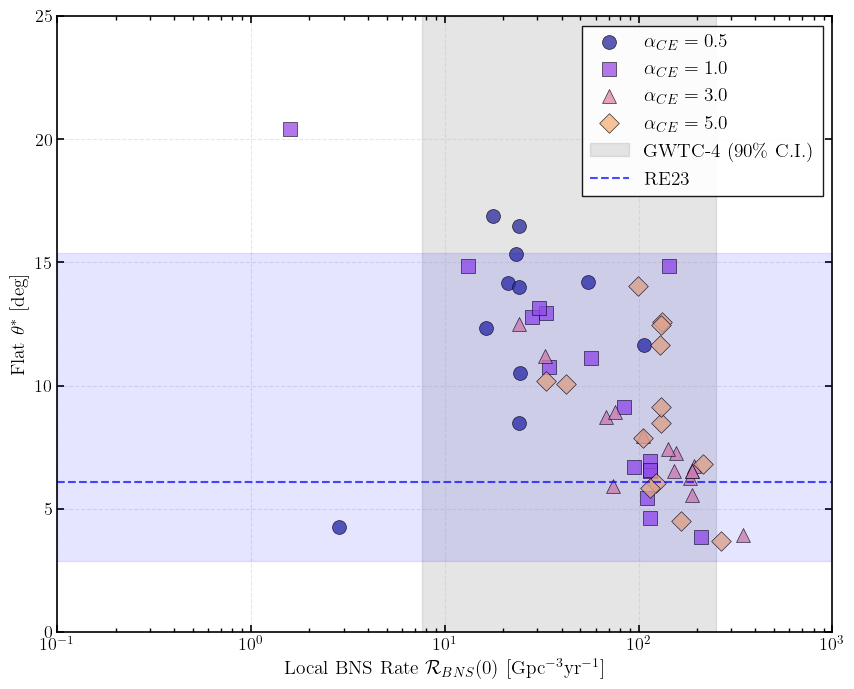

In [46]:
plotter_fj.plot_theta_star_robust_vs_rate(label_flag = 1)

In [34]:
%load_ext autoreload
%autoreload 2

from src.plots_oop_epsilon import LogNormalModelPlotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
# For Log-Normal Theta models (6 parameters)
run_name = "ProductionPop_LogNorm_10k_new_new"
BASE_DIR_LN = Path(run_name)
OUTPUT_DIR_LN = Path("Output_files") / run_name
OUTPUT_DIR_LN.mkdir(parents=True, exist_ok=True)

plotter_ln = LogNormalModelPlotter(
    samp_names=SAMP_NAMES,
    base_dir=str(BASE_DIR_LN),
    data_files_dir=str(DATA_FILES_DIR),
    output_dir=str(OUTPUT_DIR_LN),
    discard=300,
    thin=20,
    k_params=6,
    theta_c_idx=4,  # Index of log10(theta_c_median)
    fj_idx=5,
)

Loading and processing model data...
Successfully processed 64 models.


Could not compute theta* for model fiducial_klencki_A0.5
Could not compute theta* for model fiducial_Hrad_A1.0
Could not compute theta* for model fiducial_klencki_A1.0
Could not compute theta* for model fiducial_HGoptimistic_A3.0
Could not compute theta* for model fiducial_notides_pericirc_A3.0
Could not compute theta* for model fiducial_kick265_A5.0
Could not compute theta* for model fiducial_l01_A5.0
Could not compute theta* for model fiducial_xuli_A5.0
Saved plot to Output_files/ProductionPop_LogNorm_10k_new_new/theta_star_robust_vs_rate.pdf


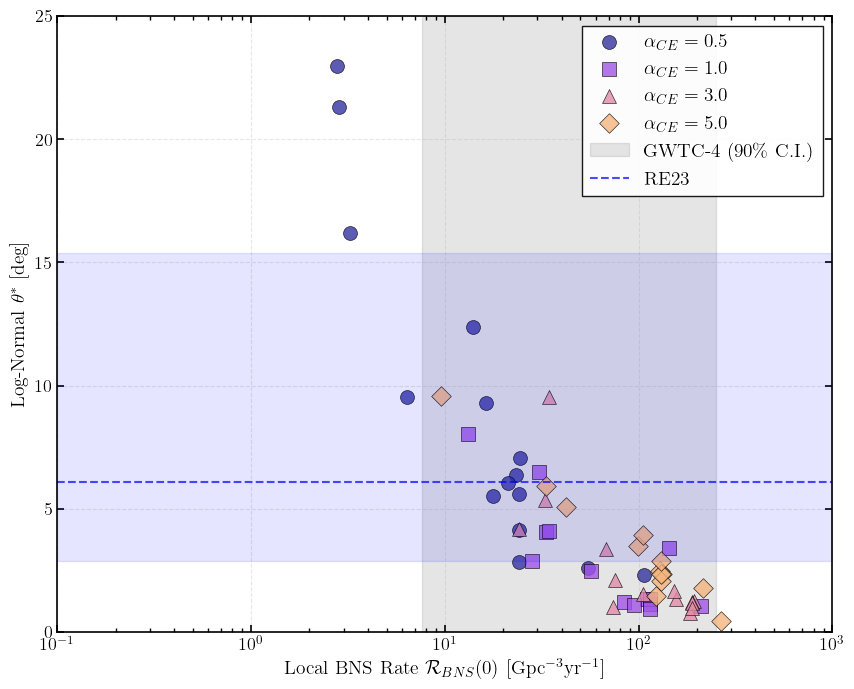

Saved plot to Output_files/ProductionPop_LogNorm_10k_new_new/lognormal_tail_fraction_vs_rate.pdf


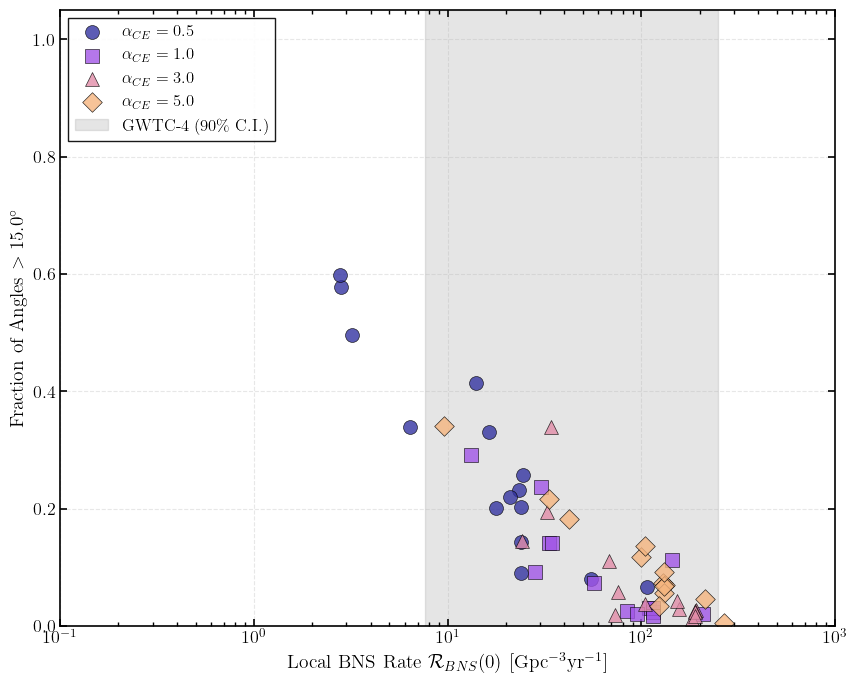

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Local BNS Rate $\\mathcal{R}_{BNS}(0)$ [Gpc$^{-3}$yr$^{-1}$]', ylabel='Fraction of Angles $> 15.0^\\circ$'>)

In [ ]:
plotter_ln.plot_theta_star_robust_vs_rate(label_flag=2)


Saved plot to Output_files/ProductionPop_LogNorm_10k_new_new/lognormal_tail_fraction_vs_rate.pdf


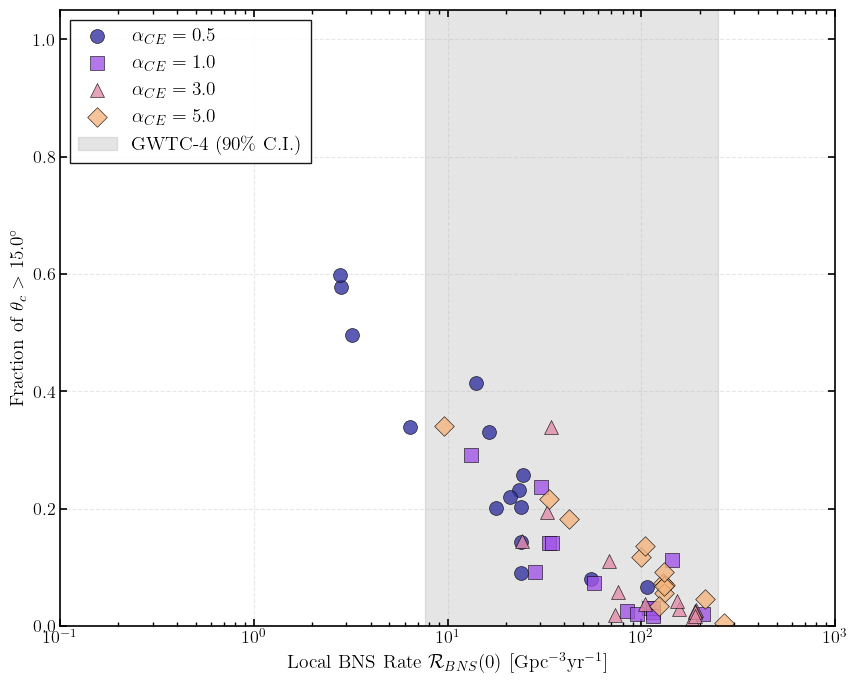

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Local BNS Rate $\\mathcal{R}_{BNS}(0)$ [Gpc$^{-3}$yr$^{-1}$]', ylabel='Fraction of $\\theta_c > 15.0^\\circ$'>)

In [60]:
plotter_ln.plot_lognormal_tail_fraction_vs_rate()